In [49]:
#Input files
import pandas as pd
from pathlib import Path
import math 

#read input files 
input_file = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\nameplate_capacity_demand_update.csv") #Calliope model output
input_storage = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\storage_capacity.csv") #Calliope model storage output
baseline_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\nameplate_capacity_2025.csv") #IRENA data
input_vintage = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\capacity_vintages_EU.csv") #Vintages
material_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Material\material_intensities.csv") #Material intensities
capacity_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\EU_capacities.csv") #Total EU capacities since 2016

df = pd.read_csv(input_file)
df_storage = pd.read_csv(input_storage)
df_2025 = pd.read_csv(baseline_input, sep=";")
material_intensities = pd.read_csv(material_input, sep=";")
df_capacities =pd.read_csv(capacity_input, sep=";")



with open(input_vintage, "r", encoding="utf-8-sig") as f:
    first_line = f.readline().strip().lower()

skiprows = 1 if first_line.startswith("sep=") else 0

df_vintage = pd.read_csv(
    input_vintage,
    sep=";",
    skiprows=skiprows
)


In [50]:
# read all csv's correctly 

#df_2025
df_2025 = df_2025.copy()
df_2025.columns = df_2025.columns.str.strip()

# Tech en country opschonen
df_2025["tech"] = df_2025["tech"].str.strip()
df_2025["country"] = df_2025["country"].str.strip()

# capacity (TW) als getal inlezen
df_2025["capacity (TW)"] = (
    df_2025["capacity (TW)"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_2025["capacity (TW)"] = pd.to_numeric(
    df_2025["capacity (TW)"],
    errors="coerce"
).fillna(0)

#df_vintage
df_vintage = df_vintage.copy()
df_vintage.columns = df_vintage.columns.str.strip()

df_vintage["country"] = df_vintage["country"].astype(str).str.strip()
df_vintage["tech"] = df_vintage["tech"].astype(str).str.strip().str.lower()

df_vintage["vintage_year"] = pd.to_numeric(
    df_vintage["vintage_year"],
    errors="coerce"
).astype("Int64")

df_vintage["capacity_TW"] = (
    df_vintage["capacity_TW"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df_vintage["capacity_TW"] = pd.to_numeric(
    df_vintage["capacity_TW"],
    errors="coerce"
).fillna(0)

# Capacities 
df_capacities["capacity (TW)"] = (
    df_capacities["capacity (TW)"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df_capacities["capacity_TW"] = pd.to_numeric(
    df_capacities["capacity (TW)"],
    errors="coerce"
).fillna(0)


In [73]:
#Support dictionary

#Select weather year 2018 for analysis
#Select one option, comment other
#df_2018 = df[df["weather_year"] == 2018].copy()  #When using demand-update
df_2018 = df.copy()  #When using non-updated demand

df_storage = df_storage.copy()

# Merge hubs from same countries
df_2018["country"] = df_2018["locs"].str.split("_").str[0]
df_storage["country"] = df_storage["locs"].str.split("_").str[0]

# Capacity must be numeric
df_2018["nameplate_capacity"] = pd.to_numeric(
    df_2018["nameplate_capacity"],
    errors="coerce"
)

df_storage["storage_capacity"] = pd.to_numeric(
    df_storage["storage_capacity"],
    errors="coerce"
)

# Add up capacities for each country and technology
result = (
    df_2018
    .groupby(["country", "techs", "unit"], as_index=False)["nameplate_capacity"]
    .sum()
    .sort_values(["country", "techs", "unit"])
)

result_storage = (
    df_storage
    .groupby(["country", "techs", "unit"], as_index=False)["storage_capacity"]
    .sum()
    .sort_values(["country", "techs", "unit"])
)


# Dictionary : {country: {tech: capacity}}
capacity_dict = {}

for _, row in result.iterrows():
    country = row["country"]
    tech = row["techs"]
    capacity = row["nameplate_capacity"]
    unit = row["unit"]

    if pd.notna(capacity):
        if country not in capacity_dict:
            capacity_dict[country] = {}

        capacity_dict[country][tech] = capacity *1000
        
# Dictionary : {country: {tech: capacity}}
storage_capacity_dict = {}

for _, row in result_storage.iterrows():
    country = row["country"]
    tech = row["techs"]
    capacity = row["storage_capacity"]
    unit = row["unit"]

    if pd.notna(capacity):
        if country not in storage_capacity_dict:
            storage_capacity_dict[country] = {}

        storage_capacity_dict[country][tech] = capacity *1000



In [70]:
# Only take into account EU countries (minus Malta) and some technologies
EU_countries = [
    "AUT",  # Austria
    "BEL",  # Belgium
    "BGR",  # Bulgaria
    "CYP",  # Cyprus
    "CZE",  # Czechia
    "DEU",  # Germany
    "DNK",  # Denmark
    "ESP",  # Spain
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "GRC",  # Greece
    "HRV",  # Croatia
    "HUN",  # Hungary
    "IRL",  # Ireland
    "ITA",  # Italy
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    "NLD",  # Netherlands
    "POL",  # Poland
    "PRT",  # Portugal
    "ROU",  # Romania
    "SVK",  # Slovakia
    "SVN",  # Slovenia
    "SWE",  # Sweden
]
 
tech_groups = {
    "solar": ["open_field_pv", "roof_mounted_pv"],
    "onshore wind": ["wind_onshore"],
    "offshore wind": ["wind_offshore"],
    "batteries": ["battery"]
    #"bioenergy": ["biofuel_supply"],
    #"wind": ["wind_onshore", "wind_offshore"],
}



In [74]:
#Capacities 2025
# Dictionary 1:
# {Counry: {technology: capacity_2025}}
EU_capacities_2025 = {}

for country in EU_countries:
    EU_capacities_2025[country] = {}

    for tech_group in tech_groups:
        total_capacity = df_2025.loc[
            (df_2025["country"] == country) &
            (df_2025["tech"] == tech_group),
            "capacity (TW)"
        ].sum()

        EU_capacities_2025[country][tech_group] = float(total_capacity) *1000


# Dictionary 2:
# {Technology: total_EU_capacity_2025}
EU_total_capacities_2025 = {}

for tech_group in tech_groups:
    total_capacity = 0

    for country in EU_capacities_2025:
        total_capacity += EU_capacities_2025[country][tech_group] 

    EU_total_capacities_2025[tech_group] = float(total_capacity) 


# Print dictionary 1
print("EU capacities per country in 2025:")
for country, techs in EU_capacities_2025.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacities in 2025:")
for tech_group, capacity in EU_total_capacities_2025.items():
    print(f"{tech_group}: {capacity:.6f}")

EU capacities per country in 2025:
AUT {'solar': 10.304, 'onshore wind': 4.292, 'offshore wind': 0.0, 'batteries': 0.13573}
BEL {'solar': 10.398, 'onshore wind': 3.589, 'offshore wind': 2.262, 'batteries': 1.33465}
BGR {'solar': 5.91, 'onshore wind': 0.7060000000000001, 'offshore wind': 0.0, 'batteries': 4.00887}
CYP {'solar': 0.861, 'onshore wind': 0.17, 'offshore wind': 0.0, 'batteries': 0.0}
CZE {'solar': 4.5409999999999995, 'onshore wind': 0.36900000000000005, 'offshore wind': 0.0, 'batteries': 0.04304}
DEU {'solar': 106.272, 'onshore wind': 68.135, 'offshore wind': 9.673, 'batteries': 4.1871599999999995}
DNK {'solar': 5.046, 'onshore wind': 4.9030000000000005, 'offshore wind': 2.644, 'batteries': 0.36177}
ESP {'solar': 44.903, 'onshore wind': 33.296, 'offshore wind': 0.005, 'batteries': 0.5273800000000001}
EST {'solar': 0.9840000000000001, 'onshore wind': 0.705, 'offshore wind': 0.0, 'batteries': 0.27109999999999995}
FIN {'solar': 1.5659999999999998, 'onshore wind': 9.350999999999

In [77]:
#Capacities 2050
# Dictionary 1:
# {Counry: {technology: capacity_2050}}
EU_capacities_2050 = {}

for country in EU_countries:
    # Alleen landen meenemen die daadwerkelijk in capacity_dict staan
    if country in capacity_dict:
        EU_capacities_2050[country] = {}

        for tech_group, model_techs in tech_groups.items():
            if tech_group == "batteries":
                source_dict = storage_capacity_dict 
            else:
                source_dict = capacity_dict 

            total_capacity_EU = 0

            for model_tech in model_techs:
                total_capacity_EU += source_dict[country].get(model_tech, 0)

            EU_capacities_2050[country][tech_group] = total_capacity_EU


# Dictionary 2:
# {Technology: total_EU_capacity_2050}
EU_total_capacities_2050 = {}

for tech_group in tech_groups:
    total_capacity_EU = 0

    for country in EU_capacities_2050:
        total_capacity_EU += EU_capacities_2050[country][tech_group]

    EU_total_capacities_2050[tech_group] = total_capacity_EU 


# Print dictionary 1
print("EU capacities per country in 2050 (GW):")
for country, techs in EU_capacities_2050.items():
    print(country, techs)
 
# Print dictionary 2    
print("\nTotal EU capacities in 2050 (GW):")
for tech_group, capacity in EU_total_capacities_2050.items():
    print(f"{tech_group}: {capacity :.6f}")

EU capacities per country in 2050 (GW):
AUT {'solar': 18.436573275328552, 'onshore wind': 80.79131944814353, 'offshore wind': 0, 'batteries': 0.0272293426318733}
BEL {'solar': 29.5234303398546, 'onshore wind': 62.5081651866342, 'offshore wind': 0, 'batteries': 0.0034265560275208}
BGR {'solar': 97.6521611379877, 'onshore wind': 0.002992077157274971, 'offshore wind': 0, 'batteries': 0.0262216479656817}
CYP {'solar': 12.4480713283812, 'onshore wind': 6.2870216330462, 'offshore wind': 0, 'batteries': 0.0650314789437594}
CZE {'solar': 0.11006159139776647, 'onshore wind': 110.14669856035532, 'offshore wind': 0, 'batteries': 0.020530165643623602}
DEU {'solar': 509.2795914482644, 'onshore wind': 192.14100218511183, 'offshore wind': 0.0018730580923945275, 'batteries': 0.03762764680495835}
DNK {'solar': 32.9937318329358, 'onshore wind': 158.14442108107679, 'offshore wind': 0, 'batteries': 0.005932643369749269}
ESP {'solar': 482.0264497192129, 'onshore wind': 345.5754778529423, 'offshore wind': 0

In [55]:
# Capacity difference per country from 2025 to 2050
EU_difference = {}
for country in EU_countries:
    EU_difference [country] = {}
    
    for tech in EU_total_capacities_2025.keys():
        difference = EU_capacities_2050[country].get(tech,0) - EU_capacities_2025[country].get(tech,0)
        EU_difference[country][tech]=difference
    
# Total capacity difference from 2025 to 2050    
EU_total_difference = {}
EU_relative_difference = {}
for tech in EU_total_capacities_2050.keys():
    difference = EU_total_capacities_2050[tech] - EU_total_capacities_2025[tech]
    EU_total_difference[tech] = difference
    if EU_total_capacities_2025[tech] > 0:
        EU_relative_difference[tech] = round(difference / EU_total_capacities_2025[tech] *100, 2)
    else:
        EU_relative_difference[tech] = "N.A."
    
    
# Print dictionary 1
print("EU capacities differences per country in 2050 (TW):")
for country, techs in EU_difference.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacity difference in 2050 (TW):")
for tech_group, capacity in EU_total_difference.items():
    print(f"{tech_group}: {capacity:.6f} (+{EU_relative_difference[tech_group]}% from 2025 to 2050)")
    

EU capacities differences per country in 2050 (TW):
AUT {'solar': 0.008132573275328552, 'onshore wind': 0.07649931944814352, 'offshore wind': 0.0, 'batteries': -0.00010850065736812671}
BEL {'solar': 0.0191254303398546, 'onshore wind': 0.0589191651866342, 'offshore wind': -0.002262, 'batteries': -0.001331223443972479}
BGR {'solar': 0.09174216113798771, 'onshore wind': -0.000703007922842725, 'offshore wind': 0.0, 'batteries': -0.0039826483520343185}
CYP {'solar': 0.0115870713283812, 'onshore wind': 0.0061170216330462, 'offshore wind': 0.0, 'batteries': 6.503147894375939e-05}
CZE {'solar': -0.004430938408602233, 'onshore wind': 0.10977769856035532, 'offshore wind': 0.0, 'batteries': -2.25098343563764e-05}
DEU {'solar': 0.40300759144826437, 'onshore wind': 0.12400600218511182, 'offshore wind': -0.009671126941907604, 'batteries': -0.004149532353195041}
DNK {'solar': 0.0279477318329358, 'onshore wind': 0.1532414210810768, 'offshore wind': -0.002644, 'batteries': -0.0003558373566302507}
ESP {

In [56]:
# Model parameters

maturity_2050 = 0.9
techs = ["solar", "onshore wind", "offshore wind", "batteries" #, "wind"
         ]

growth_params = {}
for tech in techs:
    years =[2025]
    L = EU_total_capacities_2050[tech]/maturity_2050
    growth_params[tech]={}
    for i in range(2016,2026):
        if float(df_capacities.loc[
        (df_capacities["tech"] == tech) &
        (df_capacities["year"] == i),
        "capacity (TW)"].iloc[0]) >= 0.1*L: 
            years.append(i)
    t = min(years)
    klog = math.log(81)/(2050-t)
    kgom = math.log(math.log(0.1)/math.log(0.9))/(2050-t)
    t0log = round(math.log(L/EU_total_capacities_2050[tech] - 1) /klog + 2050)
    t0gom = round(math.log(-math.log(EU_total_capacities_2050[tech]/L))/kgom +2050)
    growth_params[tech]["k_log"] = klog
    growth_params[tech]["k_gom"] =kgom
    growth_params[tech]["t0_log"] = t0log
    growth_params[tech]["t0_gom"] = t0gom

tech_params = {
    "solar": {"lifetime": 25, "beta": 4},
    "onshore wind": {"lifetime": 25, "beta": 4},
    "offshore wind": {"lifetime": 25, "beta": 4},
    "batteries": {"lifetime": 15, "beta": 4},
    #"wind": {"lifetime": 25, "beta": 4}
}

# L_bio = EU_total_capacities_2050["bioenergy"] / maturity_2050
# bio_years = [2025]
# for i in range(2016,2026):
#         if float(df_capacities.loc[
#         (df_capacities["tech"] == "bioenergy") &
#         (df_capacities["year"] == i),
#         "capacity (TW)"].iloc[0]) >= 0.1*L_bio: 
#             bio_years.append(i)
# t_bio = min(bio_years)
# bio_k_log = math.log(81)/(2050-t_bio)
# bio_k_gom = math.log(math.log(0.1)/math.log(0.9))/(2050-t_bio)
# biofuel_params ={
#     "k_log" : bio_k_log,
#     "t0_log" : round(math.log(L_bio/EU_total_capacities_2050["bioenergy"] - 1) /bio_k_log + 2050),
#     "k_gom" : bio_k_gom,
#     "t0_gom" :round(math.log(-math.log(EU_total_capacities_2050["bioenergy"]/L_bio))/bio_k_gom +2050)

# }

start_year = 2025
end_year = 2050


In [57]:

# Growth functions
def linear_growth(cap_begin, cap_end):
    return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)


def logistic_growth(year, cap_begin, cap_end, k, t0):
    
    raw_start = L / (1 + math.exp(-k * (start_year - t0)))
    raw_end = L / (1 + math.exp(-k * (end_year - t0)))
    raw_year = L / (1 + math.exp(-k * (year - t0)))

    s = (raw_year - raw_start) / (raw_end - raw_start)

    if cap_end > cap_begin:
        return cap_begin + (cap_end - cap_begin) * s
    else:
        return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)

def gompertz_growth(year, cap_begin, cap_end, k, t0):
   
    raw_start = L*math.exp(-math.exp(-k * (start_year - t0)))
    raw_end = L*math.exp(-math.exp(-k * (end_year - t0)))
    raw_year = L*math.exp(-math.exp(-k * (year - t0)))

    s = (raw_year - raw_start) / (raw_end - raw_start)

    if cap_end > cap_begin:
        return cap_begin + (cap_end - cap_begin) * s
    else:
        return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)
    
# Weibull function 
def weibull(year, vintage_year, lifetime, beta):
    """
    Survival fraction of capacity built in vintage_year and observed in year.

    This assumes vintage capacity = capacity originally built in that vintage year.
    """
    age = year - vintage_year

    if age < 0:
        return 0

    return math.exp(-((age / lifetime) ** beta))    

In [58]:
# biofuel use per year

# annual_biofuel_use = {}
# biofuel_total = {
#     year: 0
#     for year in range(start_year + 1, end_year + 1)
# }
# for country in EU_countries:
#     annual_biofuel_use [country] = {}
    
#     biofuel_use_2025 = EU_capacities_2025[country]["bioenergy"]
#     biofuel_use_2050 = EU_capacities_2050[country]["bioenergy"]
    
#     for year in range(start_year + 1, end_year + 1):
            
#             years_after_start = year - start_year
                        
#             biofuel_use = linear_growth(cap_begin = biofuel_use_2025,
#                                         cap_end = biofuel_use_2050)
            
#             annual_biofuel_use[country][year] = biofuel_use
#             biofuel_total[year] += biofuel_use

In [124]:
# Annual buildout calculation
# annual_buildout[country][tech][year] = required new capacity
annual_buildout = {}

# vintage_dict[country][tech] = newly built capacity
vintage_dict = {}

# DataFrame output
records = []


for country in EU_countries:
    annual_buildout[country] = {}
    vintage_dict[country] = {}

    for tech in techs:
        params = tech_params[tech]
        params_growth = growth_params[tech]

        lifetime = params["lifetime"]
        beta = params["beta"]
        k_log = params_growth["k_log"]
        t0_log = params_growth["t0_log"]
        k_gom = params_growth["k_gom"]
        t0_gom = params_growth["t0_gom"]

        capacity_2025 = float(EU_capacities_2025[country][tech])
        capacity_2050 = float(EU_capacities_2050[country][tech])

        annual_buildout[country][tech] = {}

        # Add existing Vintages from before 2026
        vintage_rows = df_vintage.loc[
            (df_vintage["country"] == country) &
            (df_vintage["tech"] == tech)
        ]

        vintages = []

        for _, vintage_row in vintage_rows.iterrows():
            vintages.append({
                "year": int(vintage_row["vintage_year"]),
                "capacity": float(vintage_row["capacity_TW"])
            })


       # Scale Vintages to match 2025 capacity 
        surviving_vintage_capacity_2025 = 0

        for vintage in vintages:
            if vintage["year"] <= start_year:
                survival_2025 = weibull(
                    year=start_year,
                    vintage_year=vintage["year"],
                    lifetime=lifetime,
                    beta=beta
                )

                surviving_vintage_capacity_2025 += vintage["capacity"] * survival_2025


        if surviving_vintage_capacity_2025 > 0 and capacity_2025 > 0:
            scale_factor = capacity_2025 / surviving_vintage_capacity_2025

            for vintage in vintages:
                if vintage["year"] <= start_year:
                    vintage["capacity"] *= scale_factor
                    
        # Loop over years from start (2025) to end (2050)
        for year in range(start_year + 1, end_year + 1):
            years_after_start = year - start_year

            # Target capacity based on growth function
            target_capacity = linear_growth(
                                              cap_begin=capacity_2025,
                                              cap_end=capacity_2050,
                                            
                                               )

            # Calculate surviving capacity from all vintages
            operating_capacity_before_build = 0

            for vintage in vintages:
                survival = weibull(
                    year=year,
                    vintage_year=vintage["year"],
                    lifetime=lifetime,
                    beta=beta
                )

                operating_capacity_before_build += vintage["capacity"] * survival

            # New capacity required in this year
            new_capacity_required = target_capacity - operating_capacity_before_build
            

            # Add new capacity to vintage dictionary
            vintages.append({
                "year": year,
                "capacity": new_capacity_required
            })

            # Capacity after new build
            operating_capacity_after_build = (
                operating_capacity_before_build + new_capacity_required
            )

            # Store annual build-out 
            annual_buildout[country][tech][year] = new_capacity_required

            # Store detailed record
            records.append({
                "country": country,
                "tech": tech,
                "year": year,
                "target_capacity_TW": target_capacity,
                "operating_capacity_before_build_TW": operating_capacity_before_build,
                "new_capacity_required_TW": new_capacity_required,
                "operating_capacity_after_build_TW": operating_capacity_after_build,
                "capacity_2025_TW": capacity_2025,
                "capacity_2050_TW": capacity_2050,
            })

        # Store final vintage list for for each country and tech
        vintage_dict[country][tech] = vintages.copy()

In [125]:
# Store data

# Dataframe with all results
annual_buildout_df = pd.DataFrame(records)

# Total annual build-out for each tech

EU_annual_buildout = (
    annual_buildout_df
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_TW"]
    .sum()
    .sort_values(["year", "tech"])
)



# Annnual build-out for each tech in each country

EU_annual_buildout_dict = {}

for tech in techs:
    EU_annual_buildout_dict[tech] = {}

    for year in range(start_year + 1, end_year + 1):
        value = EU_annual_buildout.loc[
            (EU_annual_buildout["tech"] == tech) &
            (EU_annual_buildout["year"] == year),
            "new_capacity_required_TW"
        ].sum()

        EU_annual_buildout_dict[tech][year] = float(value)





# Total operation capacity

operating_capacity_dict = {}

for _, row in annual_buildout_df.iterrows():
    country = row["country"]
    tech = row["tech"]
    year = int(row["year"])
    operating_capacity = float(row["operating_capacity_after_build_TW"])

    if country not in operating_capacity_dict:
        operating_capacity_dict[country] = {}

    if tech not in operating_capacity_dict[country]:
        operating_capacity_dict[country][tech] = {}

    operating_capacity_dict[country][tech][year] = operating_capacity




Figures

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Selecteer technologieën en jaren
techs_to_plot = ["solar", "onshore wind", "offshore wind"]

df_buildout = annual_buildout_df[
    (annual_buildout_df["tech"].isin(techs_to_plot)) &
    (annual_buildout_df["year"] >= 2026) &
    (annual_buildout_df["year"] <= 2050)
].copy()

# TW naar GW
df_buildout["new_capacity_required_GW"] = (
    df_buildout["new_capacity_required_TW"] * 1000
)

# Totaal per jaar en technologie over alle landen
EU_buildout_by_year = (
    df_buildout
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_GW"]
    .sum()
)

# Pivot voor plotten
buildout_pivot = EU_buildout_by_year.pivot(
    index="year",
    columns="tech",
    values="new_capacity_required_GW"
).fillna(0)

# Zorg dat kolommen in vaste volgorde staan
buildout_pivot = buildout_pivot.reindex(columns=techs_to_plot).fillna(0)

print(buildout_pivot.head())

tech          solar   onshore wind  offshore wind
year                                             
2026   98963.826603  102867.804824    -669.749103
2027   99507.138867  103392.581338    -628.533206
2028  100125.522592  103895.028538    -581.054929
2029  100830.382774  104376.979849    -527.275477
2030  101636.234414  104848.028649    -467.458532


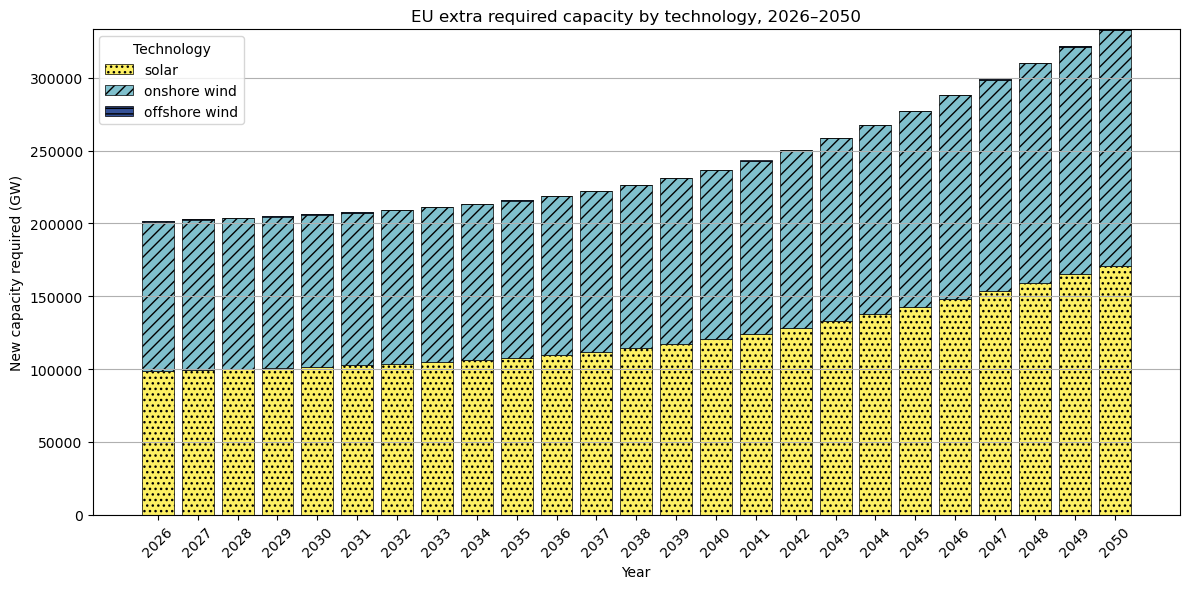

In [127]:
colors = {
    "solar": "#FDF063",
    "onshore wind": "#80C0CD",
    "offshore wind": "#355197",
    "batteries": "#D2ABC3"
}

hatches = {
    "solar": "...",
    "onshore wind": "///",
    "offshore wind": "---",
    "batteries": "++"
}

plt.figure(figsize=(12, 6))

bottom = np.zeros(len(buildout_pivot))

for tech in techs_to_plot:
    plt.bar(
        buildout_pivot.index,
        buildout_pivot[tech],
        bottom=bottom,
        label=tech,
        color=colors.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.5,
        hatch=hatches.get(tech, ""),
    )
    
    bottom += buildout_pivot[tech].values

plt.xlabel("Year")
plt.ylabel("New capacity required (GW)")
plt.title("EU extra required capacity by technology, 2026–2050")
plt.xticks(buildout_pivot.index, rotation=45)
plt.legend(title="Technology")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [128]:
# Selecteer technologieën en jaren
techs_to_plot = ["batteries"]

df_buildout = annual_buildout_df[
    (annual_buildout_df["tech"].isin(techs_to_plot)) &
    (annual_buildout_df["year"] >= 2026) &
    (annual_buildout_df["year"] <= 2050)
].copy()

# TW naar GW
df_buildout["new_capacity_required_GW"] = (
    df_buildout["new_capacity_required_TW"] * 1000
)

# Totaal per jaar en technologie over alle landen
EU_buildout_by_year = (
    df_buildout
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_GW"]
    .sum()
)

# Pivot voor plotten
buildout_pivot = EU_buildout_by_year.pivot(
    index="year",
    columns="tech",
    values="new_capacity_required_GW"
).fillna(0)

# Zorg dat kolommen in vaste volgorde staan
buildout_pivot = buildout_pivot.reindex(columns=techs_to_plot).fillna(0)

print(buildout_pivot.head())

tech    batteries
year             
2026  2301.746347
2027  2431.543147
2028  2587.142965
2029  2768.644788
2030  2974.589733


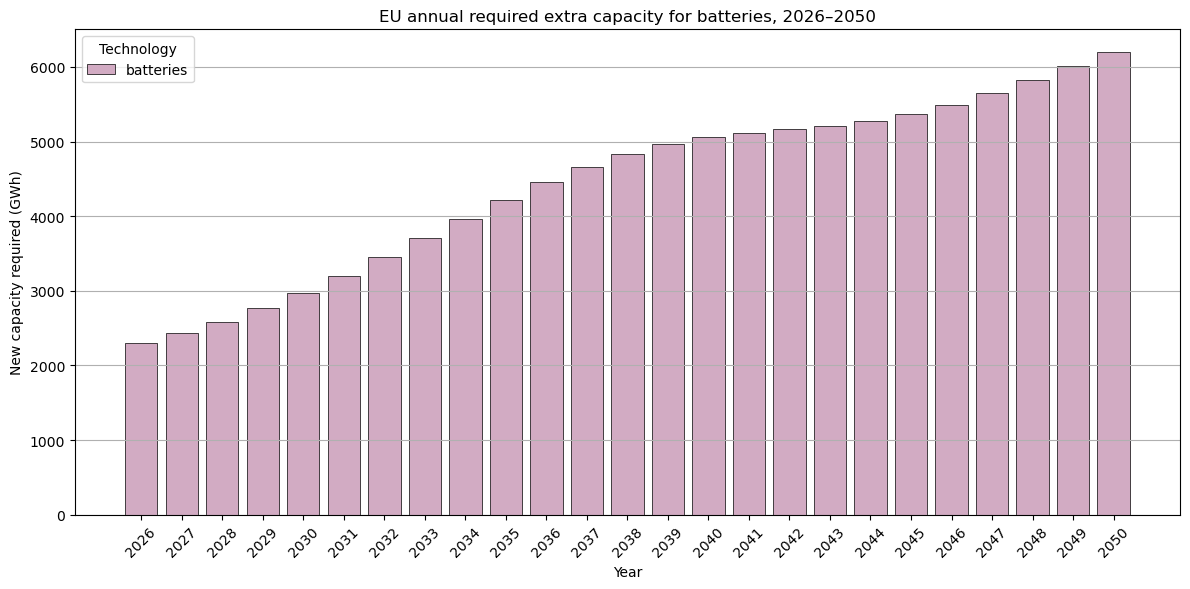

In [129]:
plt.figure(figsize=(12, 6))

bottom = np.zeros(len(buildout_pivot))

for tech in techs_to_plot:
    plt.bar(
        buildout_pivot.index,
        buildout_pivot[tech],
        bottom=bottom,
        label=tech,
        color=colors.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.5,
    )
    bottom += buildout_pivot[tech].values

plt.xlabel("Year")
plt.ylabel("New capacity required (GWh)")
plt.title("EU annual required extra capacity for batteries, 2026–2050")
plt.xticks(buildout_pivot.index, rotation=45)
plt.legend(title="Technology")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

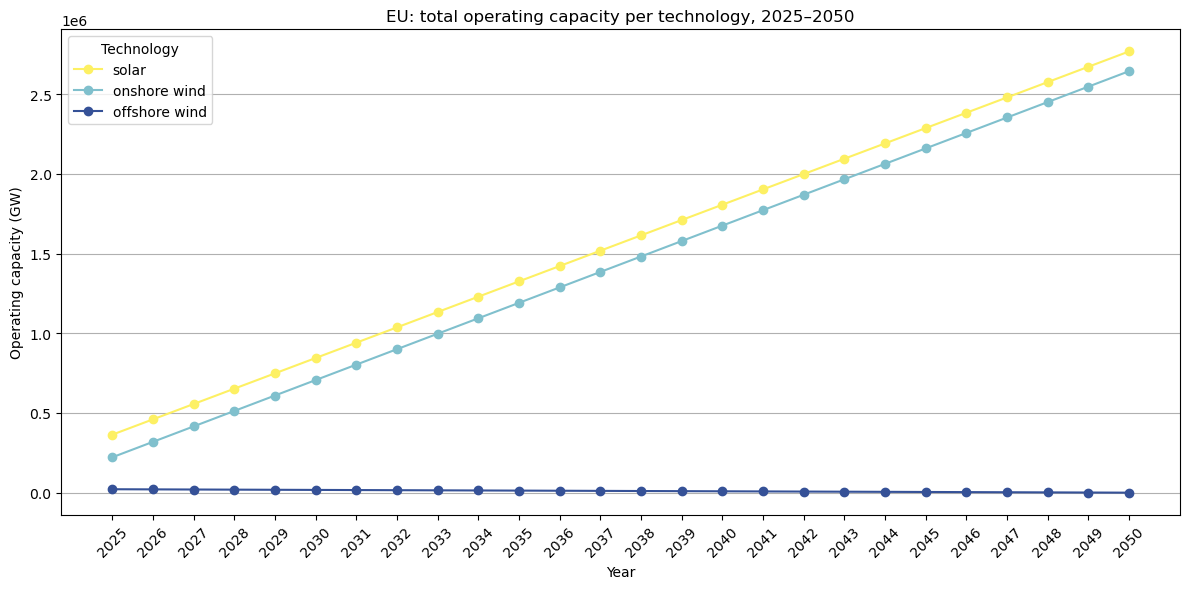

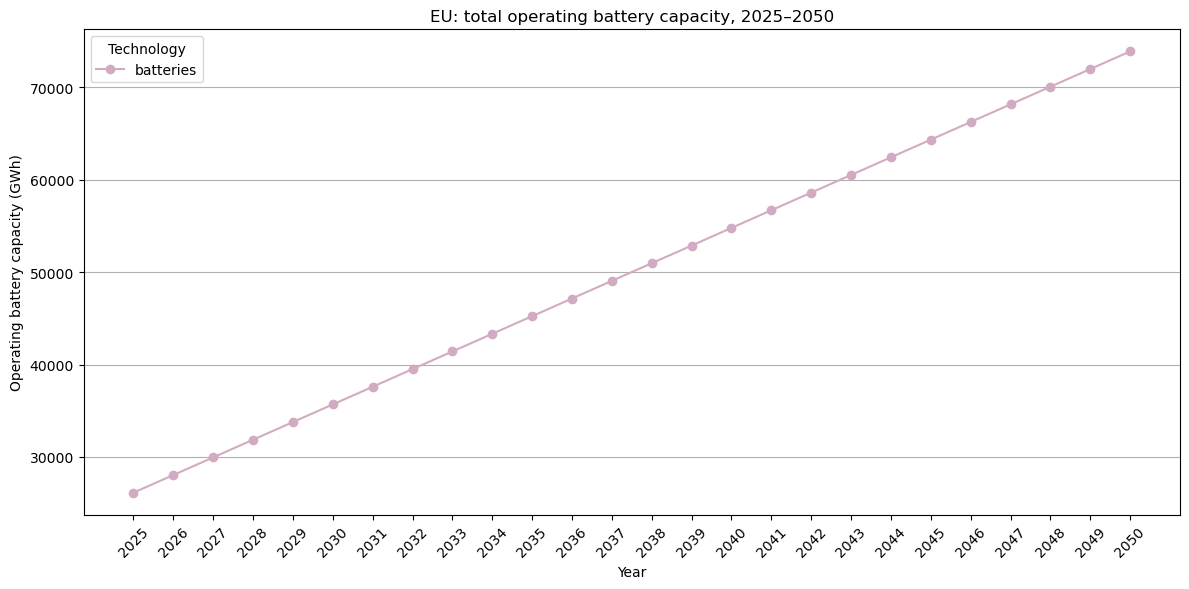

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

techs_to_plot = ["solar", "onshore wind", "offshore wind"]
battery_tech = "batteries"

start_year = 2025
end_year = 2050


# ---------------------------------------------------------
# Aggregate EU operating capacity from annual_buildout_df
# ---------------------------------------------------------

eu_capacity_df = (
    annual_buildout_df
    .groupby(["year", "tech"], as_index=False)["operating_capacity_after_build_TW"]
    .sum()
)

# Convert TW to GW
eu_capacity_df["operating_capacity_GW"] = (
    eu_capacity_df["operating_capacity_after_build_TW"] * 1000
)


# ---------------------------------------------------------
# Add 2025 start capacities
# ---------------------------------------------------------

start_rows = []

for tech in techs_to_plot + [battery_tech]:
    capacity_2025_GW = sum(
        EU_capacities_2025[country][tech] * 1000
        for country in EU_countries
        if country in EU_capacities_2025
    )

    start_rows.append({
        "year": 2025,
        "tech": tech,
        "operating_capacity_GW": capacity_2025_GW
    })

start_df = pd.DataFrame(start_rows)

plot_data = pd.concat(
    [
        start_df,
        eu_capacity_df[["year", "tech", "operating_capacity_GW"]]
    ],
    ignore_index=True
)

plot_data = plot_data.sort_values(["tech", "year"])


# ---------------------------------------------------------
# Figure 1: EU solar and wind operating capacity
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

for tech in techs_to_plot:
    df_tech = plot_data[plot_data["tech"] == tech]

    plt.plot(
        df_tech["year"],
        df_tech["operating_capacity_GW"],
        marker="o",
        label=tech,
        color=colors.get(tech, "grey"),
    )

plt.xlabel("Year")
plt.ylabel("Operating capacity (GW)")
plt.title("EU: total operating capacity per technology, 2025–2050")
plt.xticks(range(start_year, end_year + 1), rotation=45)
plt.grid(True, axis="y")
plt.legend(title="Technology")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Figure 2: EU battery operating capacity
# ---------------------------------------------------------

df_battery = plot_data[plot_data["tech"] == battery_tech]

plt.figure(figsize=(12, 6))

plt.plot(
    df_battery["year"],
    df_battery["operating_capacity_GW"],
    marker="o",
    label="batteries",
    color="#D2ABC3",
)

plt.xlabel("Year")
plt.ylabel("Operating battery capacity (GWh)")
plt.title("EU: total operating battery capacity, 2025–2050")
plt.xticks(range(start_year, end_year + 1), rotation=45)
plt.grid(True, axis="y")
plt.legend(title="Technology")

plt.tight_layout()
plt.show()

Material Demand

In [131]:
buildout = annual_buildout_df[
    [
        "country",
        "year",
        "tech",
        "new_capacity_required_TW"
    ]
].copy()

# Alleen positieve nieuwbouw meenemen
buildout["new_capacity_required_TW"] = (
    buildout["new_capacity_required_TW"].clip(lower=0)
)

material_demand = buildout.merge(
    material_intensities[
        [
            "tech",
            "Material",
            "Material Intensity (ton/TW)"
        ]
    ],
    on="tech",
    how="left"
)



material_demand["material_required_tonnes"] = (
    material_demand["new_capacity_required_TW"]
    * material_demand["Material Intensity (ton/TW)"]
)



materials_country_year = (
    material_demand
    .groupby(
        ["country", "year", "Material"],
        as_index=False
    )["material_required_tonnes"]
    .sum()
)



materials_EU_year = (
    material_demand
    .groupby(
        ["year", "Material"],
        as_index=False
    )["material_required_tonnes"]
    .sum()
)


print("\nEU-totaal per jaar:")
print(materials_EU_year)


EU-totaal per jaar:
     year            Material  material_required_tonnes
0    2026            aluminum              1.467170e+09
1    2026               boron              1.235952e+06
2    2026            chromium              1.390143e+08
3    2026              cobalt              3.090159e+05
4    2026              copper              5.298791e+08
..    ...                 ...                       ...
670  2050  sum of rare earths              7.001828e+06
671  2050                 tin              1.163025e+07
672  2050            titanium              1.420865e+07
673  2050            tungsten              0.000000e+00
674  2050                zinc              2.434187e+08

[675 rows x 3 columns]
